# ML-10 — Content Action Playbook

**Lane 2 — Refresh / Content Opportunity Scoring · Build+ phase.**

This notebook turns the validated output from Weeks 4–6 into a clear, human-reviewed
content action playbook with ranked actions, reason codes, archetype→action mapping,
the decay/refresh insight, intended use, limits, human-review rules, cost/value thinking,
and monitoring/retrain triggers. It explicitly states what should NOT be automated, and
exports the ranked queue + figures to `work/outputs/` and `work/figures/`.

**Skills loaded:** `writing-honest-claims` (claim ladder: observed → directional →
decision-support; banned phrasings; effect sizes over drama) and `flyrank/flyrank-data`
(label trap: `trend_direction`/`trend_pct` are the label, never features; data gotchas).

**Evidence chain:**
- `work/outputs/w04_baseline_metrics.json` — rule baseline precision@K (full slice)
- `work/outputs/w05_model_metrics.json` — model comparison + repeated-split means
- `work/outputs/w06_validation_audit_metrics.json` — honest splits, failure examples, leakage verdict

In [1]:
%pip install -q duckdb huggingface_hub python-dotenv scikit-learn pandas matplotlib

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 25.2 -> 26.2.1
[notice] To update, run: C:\Program Files\Python313\python.exe -m pip install --upgrade pip


In [2]:
import os, json
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib
import matplotlib.pyplot as plt
from dotenv import load_dotenv

load_dotenv('../../.env')
HF_TOKEN = os.environ.get('HF_token') or os.environ.get('HF_TOKEN')
assert HF_TOKEN, 'No HF token found in .env'

import duckdb
con = duckdb.connect()
con.execute(f"CREATE OR REPLACE SECRET hf (TYPE huggingface, TOKEN '{HF_TOKEN}')")

REL  = 'hf://datasets/FlyRank/internship-warehouse'
FACT = f"read_parquet('{REL}/fact_content_daily_performance/month=2026-03/*.parquet')"
DIM  = f"read_parquet('{REL}/dim_content.parquet')"
SNAP = "DATE '2026-03-31'"

ROOT    = Path('../../').resolve()
OUT_DIR = ROOT / 'work' / 'outputs'
FIG_DIR = ROOT / 'work' / 'figures'
OUT_DIR.mkdir(parents=True, exist_ok=True)
FIG_DIR.mkdir(parents=True, exist_ok=True)

RANDOM_STATE = 42
print('Setup complete.')
print('OUT_DIR:', OUT_DIR)
print('FIG_DIR:', FIG_DIR)

Matplotlib is building the font cache; this may take a moment.


Setup complete.
OUT_DIR: C:\Users\imtia\3.Hammad\projects\flyrank\FlyRank_Internship\work\outputs
FIG_DIR: C:\Users\imtia\3.Hammad\projects\flyrank\FlyRank_Internship\work\figures


## 1. Ranked Actions + Reason Codes

*The queue: what to do first, and why, in words a human trusts.*

### 1.1 Summary of validated evidence

Label proxy `is_declining_label` = 1 when second-half March 2026 impressions < first half
(a within-month signal, not a long-run trend). Base rate: **26.8%** full slice; **34.2%**
on held-out test clients. Three models competed on a **client-grouped holdout**
(6 held-out clients, 4,495 test rows; seed 42):

| Model | p@10 | p@25 | p@50 | p@100 | ROC-AUC |
|---|---|---|---|---|---|
| Base rate (random) | 0.342 | 0.342 | 0.342 | 0.342 | — |
| Rule (visible×slipped×depth) | 0.40 | 0.40 | 0.36 | 0.33 | 0.433 |
| Logistic Regression | 0.40 | 0.32 | 0.30 | 0.33 | 0.492 |
| **Decision Tree d3** | **0.60** | **0.44** | **0.48** | **0.41** | 0.501 |
| Random Forest | 0.30 | 0.28 | 0.24 | 0.30 | 0.515 |

Over 5 repeated client-grouped splits: tree mean p@50 = **0.304** (range 0.10–0.46);
rule mean = **0.232**; base rate mean = **0.183**. No leakage in final feature set (w06).

### 1.2 Reason codes and action taxonomy

| Reason code | Condition | Action | Priority |
|---|---|---|---|
| `position_risk_with_demand` | impressions ≥ 500 **and** avg_position ≥ 10 | `refresh_review` | High |
| `model_flagged_risk` | tree_proba ≥ 0.5 but rule_score = 0 | `refresh_review` | Medium |
| `low_priority` | neither condition | `monitor` | Low |

**Decay / Refresh Insight (from w04 signal audit):** Position is the only confirmed
decline signal — decline rate rises from 13.8% at position 1–3 to **42.9%** at positions
21–50 (n=32,596, March 2026). Volume alone is **not** a decline signal (flat at ~25–28%
across impression tiers); it is a **demand gate** only. Content staleness
(`days_since_last_update`) had median = 0 days in this window — pages were recently touched,
so staleness does not separate declines in this slice. Worth monitoring as the data ages.

**Cost / Value thinking:** At p@50 = 0.48 (decision tree), ~24 of 50 reviewed pages are
genuinely declining (vs ~17 at random, base rate 0.342 × 50 ≈ 17). That is ~7 extra true
positives per 50 pages reviewed. Precision drops to 0.41 at p@100 — cap sprint reviews
at **top 25–50 rows** to maintain quality.

### 1.3 Archetype → Action Mapping

| Archetype | Definition | Recommended Action | Reason code | Human check |
|---|---|---|---|---|
| `high_demand_deep` | ≥ 3k impressions, position ≥ 10 | `refresh_review` (urgent) | `position_risk_with_demand` | Intent audit + SERP check |
| `low_demand_deep` | < 3k impressions, position ≥ 10 | `refresh_review` (lower) | `position_risk_with_demand` | Confirm query is still live |
| `aging_page_one` | Position < 10, age > 180d, engagement < 30% | `refresh_review` (watch) | `model_flagged_risk` | Check SERP feature displacement |
| `healthy_visible` | Position < 10, ≥ 1k impressions | `monitor` | `low_priority` | Flag only if tree_proba > 0.5 next run |
| `small_visible` | Position < 10, < 1k impressions | `monitor` | `low_priority` | No action; refresh ROI is low at this volume |

In [3]:
# Rebuild March 2026 page-level slice (identical contract to w03/w04/w05)
page = con.sql(
    f'''
    WITH daily AS (
        SELECT * FROM {FACT}
        WHERE ga4_data_available IS TRUE AND gsc_data_available IS TRUE
    ),
    page AS (
        SELECT
            d.client_hash_id, d.content_hash_id,
            SUM(d.gsc_impressions) AS gsc_impressions_mar,
            AVG(CASE WHEN d.gsc_avg_position > 0 THEN d.gsc_avg_position END) AS avg_position_mar,
            SUM(d.ga4_sessions) AS sessions_mar,
            SUM(d.ga4_engaged_sessions) AS engaged_sessions_mar,
            SUM(CASE WHEN d.report_date <= DATE \'2026-03-15\' THEN d.gsc_impressions ELSE 0 END) AS imp_first_half,
            SUM(CASE WHEN d.report_date >  DATE \'2026-03-15\' THEN d.gsc_impressions ELSE 0 END) AS imp_second_half
        FROM daily d GROUP BY 1, 2 HAVING SUM(d.gsc_impressions) >= 100
    )
    SELECT
        p.client_hash_id, p.content_hash_id,
        DATE_DIFF(\'day\', dc.content_created_date, {SNAP}) AS content_age_days,
        GREATEST(DATE_DIFF(\'day\', dc.content_updated_date, {SNAP}), 0) AS days_since_last_update,
        p.gsc_impressions_mar, p.avg_position_mar,
        CASE WHEN p.sessions_mar > 0
             THEN 100.0 * p.engaged_sessions_mar / p.sessions_mar END AS engagement_rate_mar,
        CASE WHEN p.imp_second_half < p.imp_first_half THEN 1 ELSE 0 END AS is_declining_label
    FROM page p JOIN {DIM} dc USING (content_hash_id)
    '''
).df()

df = (page.dropna(subset=['avg_position_mar'])
          .sort_values(['client_hash_id', 'content_hash_id'])
          .reset_index(drop=True))

print(f'Page-level slice: {len(df):,} rows, {df["client_hash_id"].nunique()} clients')
print(f'Observed declining base rate: {df["is_declining_label"].mean():.3f}')
print(f'Missing avg_position rows dropped: {len(page) - len(df):,}')

Page-level slice: 32,596 rows, 30 clients
Observed declining base rate: 0.268
Missing avg_position rows dropped: 0


In [4]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import roc_auc_score, average_precision_score

CONTRACT_FEATURES = [
    'content_age_days', 'days_since_last_update',
    'gsc_impressions_mar', 'avg_position_mar', 'engagement_rate_mar',
]

def build_matrix(frame):
    X = frame[CONTRACT_FEATURES].copy().astype(float)
    X['log_gsc_impressions_mar'] = np.log1p(X['gsc_impressions_mar'])
    X['has_engagement'] = X['engagement_rate_mar'].notna().astype(int)
    X['engagement_rate_mar'] = X['engagement_rate_mar'].fillna(0.0)
    return X[['content_age_days', 'days_since_last_update', 'avg_position_mar',
               'log_gsc_impressions_mar', 'engagement_rate_mar', 'has_engagement']]

def client_grouped_split(frame, frac=0.2, seed=RANDOM_STATE):
    rng = np.random.default_rng(seed)
    clients = np.sort(frame['client_hash_id'].drop_duplicates().to_numpy())
    order = rng.permutation(len(clients))
    n_test = max(1, int(round(len(clients) * frac)))
    test_clients = set(clients[order[:n_test]])
    is_test = frame['client_hash_id'].isin(test_clients).to_numpy()
    return ~is_test, is_test

def precision_at_k(y, score, k):
    order = np.argsort(-np.asarray(score), kind='stable')
    return float(y[order][:k].mean())

is_train, is_test = client_grouped_split(df)
tr = df.loc[is_train].reset_index(drop=True)
te = df.loc[is_test].reset_index(drop=True)
X_tr, X_te = build_matrix(tr), build_matrix(te)
y_tr = tr['is_declining_label'].astype(int).to_numpy()
y_te = te['is_declining_label'].astype(int).to_numpy()

# Keeper model: depth-3 decision tree (best p@50 on unseen clients, per w05)
tree = DecisionTreeClassifier(
    class_weight='balanced', max_depth=3, min_samples_leaf=50, random_state=RANDOM_STATE
)
tree.fit(X_tr, y_tr)
tree_proba_all = tree.predict_proba(build_matrix(df))[:, 1]
tree_proba_te  = tree.predict_proba(X_te)[:, 1]

KS = [10, 25, 50, 100]
print(f'Train: {len(tr):,} rows / {tr["client_hash_id"].nunique()} clients')
print(f'Test:  {len(te):,} rows / {te["client_hash_id"].nunique()} clients | base rate {y_te.mean():.3f}')
print('Tree precision@K on test clients:', {f"@{k}": round(precision_at_k(y_te, tree_proba_te, k), 2) for k in KS})

Train: 28,101 rows / 24 clients
Test:  4,495 rows / 6 clients | base rate 0.342
Tree precision@K on test clients: {'@10': 0.6, '@25': 0.44, '@50': 0.48, '@100': 0.41}


In [5]:
# Encode the rule + layer tree score to produce the final ranked queue
q = df.copy()
q['tree_proba'] = tree_proba_all

vis   = (q['gsc_impressions_mar'] >= 500).astype(int)
depth = q['avg_position_mar'].clip(upper=50) / 50.0
slip  = (q['avg_position_mar'] >= 10).astype(int)
q['rule_score'] = vis * slip * depth

q['reason_code'] = 'low_priority'
q.loc[q['rule_score'] > 0, 'reason_code'] = 'position_risk_with_demand'
q.loc[(q['rule_score'] == 0) & (q['tree_proba'] >= 0.5), 'reason_code'] = 'model_flagged_risk'

q['action'] = np.where(
    q['reason_code'].isin(['position_risk_with_demand', 'model_flagged_risk']),
    'refresh_review', 'monitor'
)

# Combined score: rule dominates; tree score refines within bands
q['queue_score'] = q['rule_score'] + 0.5 * q['tree_proba']
q['rank'] = q['queue_score'].rank(method='first', ascending=False).astype(int)

def assign_archetype(row):
    pos = row['avg_position_mar']
    imp = row['gsc_impressions_mar']
    age = row['content_age_days']
    eng = row['engagement_rate_mar']
    if pos >= 10 and imp >= 3000:   return 'high_demand_deep'
    elif pos >= 10 and imp < 3000:  return 'low_demand_deep'
    elif pos < 10 and age > 180 and (pd.isna(eng) or eng < 30): return 'aging_page_one'
    elif pos < 10 and imp >= 1000:  return 'healthy_visible'
    else:                           return 'small_visible'

q['archetype'] = q.apply(assign_archetype, axis=1)

out_cols = [
    'rank', 'content_hash_id', 'client_hash_id',
    'rule_score', 'tree_proba', 'queue_score',
    'reason_code', 'action', 'archetype',
    'gsc_impressions_mar', 'avg_position_mar',
    'content_age_days', 'days_since_last_update',
    'engagement_rate_mar', 'is_declining_label',
]
queue = q.sort_values('queue_score', ascending=False)[out_cols].reset_index(drop=True)

flagged    = int((queue['action'] == 'refresh_review').sum())
rule_only  = int((queue['reason_code'] == 'position_risk_with_demand').sum())
model_only = int((queue['reason_code'] == 'model_flagged_risk').sum())

print(f'Total queue rows: {len(queue):,}')
print(f'  refresh_review: {flagged:,}  (rule-driven: {rule_only:,} | model-only: {model_only:,})')
print(f'  monitor: {len(queue)-flagged:,}')
print()
print('Top 5:')
print(queue[['rank','reason_code','action','archetype',
             'gsc_impressions_mar','avg_position_mar','is_declining_label']].head(5).to_string(index=False))

Total queue rows: 32,596
  refresh_review: 17,819  (rule-driven: 8,490 | model-only: 9,329)
  monitor: 14,777

Top 5:
 rank               reason_code         action        archetype  gsc_impressions_mar  avg_position_mar  is_declining_label
   22 position_risk_with_demand refresh_review  low_demand_deep                764.0         55.006270                   1
   21 position_risk_with_demand refresh_review high_demand_deep               6443.0         50.159085                   0
   41 position_risk_with_demand refresh_review  low_demand_deep                770.0         64.068145                   1
   34 position_risk_with_demand refresh_review  low_demand_deep               1225.0         58.553312                   1
   33 position_risk_with_demand refresh_review  low_demand_deep                979.0         51.711329                   0


In [6]:
arch_summary = (
    queue.groupby('archetype', observed=True)
    .agg(
        n=('content_hash_id', 'size'),
        decline_rate=('is_declining_label', 'mean'),
        pct_refresh_review=('action', lambda x: (x == 'refresh_review').mean()),
        mean_impressions=('gsc_impressions_mar', 'mean'),
        mean_position=('avg_position_mar', 'mean'),
    )
    .sort_values('decline_rate', ascending=False)
)
arch_summary['decline_rate_pct'] = (arch_summary['decline_rate'] * 100).round(1)
arch_summary['pct_flagged_pct']  = (arch_summary['pct_refresh_review'] * 100).round(1)
arch_summary['mean_impressions'] = arch_summary['mean_impressions'].round(0).astype(int)
arch_summary['mean_position']    = arch_summary['mean_position'].round(1)

print('Archetype breakdown (sorted by observed decline rate):')
print(arch_summary[['n','decline_rate_pct','pct_flagged_pct','mean_impressions','mean_position']].to_string())

print('\nArchetype → Action mapping:')
mapping = {
    'high_demand_deep':  'refresh_review (urgent) — verify intent + SERP before committing',
    'low_demand_deep':   'refresh_review (lower priority) — confirm query is still live',
    'aging_page_one':    'refresh_review (watch) — check SERP feature displacement',
    'healthy_visible':   'monitor — flag only if tree_proba > 0.5 in future run',
    'small_visible':     'monitor — refresh ROI is low at < 1k impressions',
}
for arch, action in mapping.items():
    print(f'  {arch:20s} → {action}')

Archetype breakdown (sorted by observed decline rate):
                      n  decline_rate_pct  pct_flagged_pct  mean_impressions  mean_position
archetype                                                                                  
high_demand_deep   3245              48.9            100.0             10437           24.7
low_demand_deep   10787              34.8             95.6               782           22.0
small_visible      6810              22.4             20.7               366            5.0
aging_page_one     7909              18.0             26.4              2592            5.1
healthy_visible    3845              12.1             19.9              4997            5.0

Archetype → Action mapping:
  high_demand_deep     → refresh_review (urgent) — verify intent + SERP before committing
  low_demand_deep      → refresh_review (lower priority) — confirm query is still live
  aging_page_one       → refresh_review (watch) — check SERP feature displacement
  healthy_vis

## 2. Intended Use and Limits

*Who uses this, for what — and where it stops being valid.*

### 2.1 Intended use

This playbook is a **decision-support tool for content strategists**, not an automated system.
Its output is a ranked list of pages worth reviewing for a possible content refresh.
The strategist opens the top 25–50 rows, applies domain knowledge, and decides which pages
to actually refresh.

**What it answers:** Which pages show patterns associated with impression decline in this
period — ranked so the most actionable are first?

**What it does not answer:** Why a page declined, whether a refresh will recover it,
or how to refresh it.

### 2.2 Known limits — be explicit before anyone acts

| # | Limit | Evidence | Suggested language |
|---|---|---|---|
| 1 | **Label is within-month proxy** | `is_declining_label` = second-half < first-half March impressions; base rate 26.8% | "Directional within-month signal only — not a multi-month trend" |
| 2 | **Precision@50 ≈ 0.48 (tree) / 0.36 (rule)** | w06: fp_share_top50 = 0.36–0.40 on grouped holdout | "~1 in 2 flagged top-50 pages will not show further decline on closer inspection" |
| 3 | **High client-level variance** | Repeated-split tree p@50 range 0.10–0.46; rule 0.16–0.34 | "On some client portfolios the queue will be more accurate than on others" |
| 4 | **Page-one false negatives** | Model proba ~0.04 for position 3–5 pages that declined | "The queue under-flags position 1–10 pages; monitor top-10 pages separately" |
| 5 | **Window alignment** | March features span full month; label compares halves | "Feature and label windows share the same month — snapshot, not leading signal" |
| 6 | **One-client queue dominance** | w04 top-10: 8 of 10 from one high-volume client | "Cap per-client recommendations; deduplication is a human step" |
| 7 | **Model trained on March 2026 only** | Time-aware grouped AUC = 0.695 | "Retrain if data is > 2 months old; SERP patterns shift seasonally" |
| 8 | **100-impression gate: 93.7% of content not in scope** | 32,596 / ~519k items | "Pages with < 100 impressions are not scored — gaps are intentional" |

In [7]:
limits = [
    ('1. Label is within-month proxy',
     'is_declining_label = second-half < first-half March impressions; base rate 26.8%'),
    ('2. Precision@50: 0.48 (tree) / 0.36 (rule)',
     'w06 fp_share_top50 = 0.36-0.40; ~1-in-2 top-50 flags are false positives'),
    ('3. High client-level variance',
     'Repeated-split tree p@50 range 0.10-0.46; rule 0.16-0.34'),
    ('4. Page-one false negatives',
     'Model proba ~0.04 for position 3-5 pages that actually declined (w05 error analysis)'),
    ('5. Window alignment: features and label share March',
     'Only imp_trend_pct_mar excluded; snapshot patterns, not leading signals'),
    ('6. One-client queue dominance possible',
     'w04 top-10: 8 of 10 rows from one client; cap per-client'),
    ('7. Model trained on March 2026 only',
     'Time-aware grouped AUC = 0.695; retrain after 2 months or major SERP change'),
    ('8. 100-impression gate: 93.7% of content not scored',
     'Low-traffic pages excluded by design; they may still need attention via other means'),
]

print('KNOWN LIMITS — read before acting\n' + '='*60)
for title, detail in limits:
    print(f'  [{title}]')
    print(f'    {detail}')
    print()

KNOWN LIMITS — read before acting
  [1. Label is within-month proxy]
    is_declining_label = second-half < first-half March impressions; base rate 26.8%

  [2. Precision@50: 0.48 (tree) / 0.36 (rule)]
    w06 fp_share_top50 = 0.36-0.40; ~1-in-2 top-50 flags are false positives

  [3. High client-level variance]
    Repeated-split tree p@50 range 0.10-0.46; rule 0.16-0.34

  [4. Page-one false negatives]
    Model proba ~0.04 for position 3-5 pages that actually declined (w05 error analysis)

  [5. Window alignment: features and label share March]
    Only imp_trend_pct_mar excluded; snapshot patterns, not leading signals

  [6. One-client queue dominance possible]
    w04 top-10: 8 of 10 rows from one client; cap per-client

  [7. Model trained on March 2026 only]
    Time-aware grouped AUC = 0.695; retrain after 2 months or major SERP change

  [8. 100-impression gate: 93.7% of content not scored]
    Low-traffic pages excluded by design; they may still need attention via other means

## 3. Human Review + The No-Go List

*What a person must check before acting. What should never be automated.*

### 3.1 Required human checks (verify at least three before any refresh)

1. **Intent check:** Is the page targeting an actively-searched query?
   A page ranked deep because its topic went out of demand needs decommissioning or
   a topic pivot — not a refresh.

2. **SERP check:** Has a SERP feature (AI Overview, Featured Snippet, Shopping Pack)
   displaced organic results? If so, the impression drop may be structural — a refresh
   cannot recover the position.

3. **Seasonality check:** Does the page cover seasonal content (travel, retail, events)?
   A within-month March drop may be a seasonal shoulder, not a content problem.

4. **Page-type check:** Is this a hub, index, or collection page? These often rank deep
   by design. The rule's depth-weight over-orders them — they usually need no refresh.

5. **Single-keyword check:** Does the page get most impressions from one query? If that
   keyword's SERP re-ranked, a refresh will not restore it without topical repositioning.

6. **Cross-client deduplication:** Cap recommendations per client. A single high-volume
   client should not consume the entire sprint budget.

### 3.2 The no-go list — what must NOT be automated

| No-go case | Why |
|---|---|
| **Auto-refreshing content based on this queue** | p@50 ≈ 0.48 means ~1 in 2 top-tier flags addresses a non-declining page |
| **Publishing or deleting pages based on this score** | Score reflects one month; a score-0 page may still be strategically important |
| **Client-facing SLA commitments** | Precision varies by client (range 0.10–0.46); automation delivers wrong prioritisation to some clients |
| **Trusting scores for position 1–10 pages** | False-negative rate is high (proba ~0.04 for position 3–5 decliners); top-10 pages need separate monitoring |
| **Filling in below the 100-impression gate** | These are not scored by design; do not extrapolate |
| **Claiming causality** | Cross-sectional observational data: "refresh causes rank recovery" requires a controlled experiment |
| **Applying scores across time without retraining** | March 2026 model; applying to June 2026 without retraining may produce miscalibrated scores |

In [8]:
top10 = queue.head(10)
checks = [
    'Verify SERP: is there AI Overview or Featured Snippet displacement?',
    'Verify query is still actively searched (not retired topic)',
    'Check if this is seasonal content (March shoulder effect?)',
    'Confirm this is an article, not a hub/index/collection page',
    'Check GSC top queries: is decline from one dead keyword?',
    'Confirm client has refresh budget for this sprint',
    'Check days_since_last_update — was this recently refreshed?',
    'Assess content-to-intent match for the target keyword',
    'Verify impressions are GSC organic (not AI/referral traffic)',
    'Check if decline coincides with a promo spike that self-corrected',
]

print('Top-10 with human review checklist:\n')
for i, (_, row) in enumerate(top10.iterrows()):
    label = 'DECLINING' if row['is_declining_label'] == 1 else 'STABLE   '
    print(f"  Rank {row['rank']:>4} | {row['action']:>15} | {row['archetype']:>20} "
          f"| pos={row['avg_position_mar']:>5.1f} | imp={row['gsc_impressions_mar']:>7,.0f} | label={label}")
    print(f"          → Human check: {checks[i]}")
    print()

top50 = queue.head(50)
tp = int((top50['is_declining_label'] == 1).sum())
fp = int((top50['is_declining_label'] == 0).sum())
fp_df = top50[top50['is_declining_label'] == 0]
print(f'Top-50: {tp} true declines, {fp} false positives (p@50 = {tp/50:.2f})')
if len(fp_df) > 0:
    print(f'FP profile: mean impressions = {fp_df["gsc_impressions_mar"].mean():,.0f}, '
          f'mean position = {fp_df["avg_position_mar"].mean():.1f}')

Top-10 with human review checklist:

  Rank   22 |  refresh_review |      low_demand_deep | pos= 55.0 | imp=    764 | label=DECLINING
          → Human check: Verify SERP: is there AI Overview or Featured Snippet displacement?

  Rank   21 |  refresh_review |     high_demand_deep | pos= 50.2 | imp=  6,443 | label=STABLE   
          → Human check: Verify query is still actively searched (not retired topic)

  Rank   41 |  refresh_review |      low_demand_deep | pos= 64.1 | imp=    770 | label=DECLINING
          → Human check: Check if this is seasonal content (March shoulder effect?)

  Rank   34 |  refresh_review |      low_demand_deep | pos= 58.6 | imp=  1,225 | label=DECLINING
          → Human check: Confirm this is an article, not a hub/index/collection page

  Rank   33 |  refresh_review |      low_demand_deep | pos= 51.7 | imp=    979 | label=STABLE   
          → Human check: Check GSC top queries: is decline from one dead keyword?

  Rank   36 |  refresh_review |      low_dem

## 4. Monitoring / Retrain Triggers

*What would tell you the recommendations went stale?*

### 4.1 Monitoring signals (check monthly)

| Signal | Threshold | Response |
|---|---|---|
| **Base rate shift** | Decline rate changes > ±5 pp from 26.8% | Check for broad SERP change; recalibrate if sustained 2+ months |
| **Strategist feedback precision** | < 30% of reviewed pages were genuinely declining | Queue is miscalibrated; retrain with more recent data |
| **Feature distribution shift** | Mean avg_position shifts > 5 positions | Retrain with current month's data |
| **Model age** | > 2 months since March 2026 training | Retrain; SERP patterns shift seasonally |
| **New client addition** | Portfolio client with very different content_type mix | Apply with extra caution; assess fit before sprint use |
| **Major SERP change** | AI Overviews expansion or equivalent | Label definition (impressions-based) may lose meaning; reassess |

### 4.2 Retrain criteria — trigger when any TWO are true
- Data is > 2 months old
- Strategist feedback precision < 30%
- Base rate change > 5 pp (sustained)
- A new month of warehouse data is available

**What to keep constant:** feature set, label definition, 100-impression gate,
client-grouped split design (changing these invalidates the w06 leakage audit).

**What to adjust:** training month, SNAP date, demand gate threshold if portfolio shifts.

### 4.3 Light monitoring — no retrain needed
- Adjust top-K cap (e.g. top-25 instead of top-50) — configuration change
- Client-level filtering — query parameter, not model change
- Add a new reason code — extend taxonomy table, do not retrain
- Adjust demand gate from 500 to 300 impressions — re-score rule, no model needed

In [9]:
# Compute and print monitoring baseline numbers for this run
rule_scores_te = (
    te['avg_position_mar'].clip(upper=50) / 50.0 *
    (te['avg_position_mar'] >= 10).astype(int) *
    (te['gsc_impressions_mar'] >= 500).astype(int)
).to_numpy()

monitoring_baseline = {
    'training_slice':                 'March 2026 page-level (w03 contract)',
    'training_base_rate':             round(float(df['is_declining_label'].mean()), 3),
    'test_base_rate':                 round(float(y_te.mean()), 3),
    'test_clients':                   int(te['client_hash_id'].nunique()),
    'tree_prec50_test':               round(precision_at_k(y_te, tree_proba_te, 50), 3),
    'rule_prec50_test':               round(precision_at_k(y_te, rule_scores_te, 50), 3),
    'retrain_base_rate_delta_threshold': 0.05,
    'retrain_prec50_floor':           0.30,
    'retrain_model_age_months':       2,
}

print('Monitoring baseline (compare at next run to detect drift):\n')
for k, v in monitoring_baseline.items():
    print(f'  {k}: {v}')

Monitoring baseline (compare at next run to detect drift):

  training_slice: March 2026 page-level (w03 contract)
  training_base_rate: 0.268
  test_base_rate: 0.342
  test_clients: 6
  tree_prec50_test: 0.48
  rule_prec50_test: 0.36
  retrain_base_rate_delta_threshold: 0.05
  retrain_prec50_floor: 0.3
  retrain_model_age_months: 2


## 5. Exports for the Paper

*Write the queue and figures to `work/outputs/` and `work/figures/` — the paper builds on these.*

**What gets exported:**
1. `work/outputs/w07_ranked_action_queue.csv` — full ranked queue (**gitignored**; regenerated from this notebook)
2. `work/outputs/w07_playbook_metrics.json` — metrics receipt (**committed** to git)
3. `work/figures/w07_precision_at_k.png` — precision@K comparison chart (**committed**)
4. `work/figures/w07_archetype_breakdown.png` — archetype decline rate bar chart (**committed**)
5. `work/figures/w07_queue_score_distribution.png` — score distribution (**committed**)

In [10]:
# Export 1: ranked queue CSV (gitignored by CI)
queue_path = OUT_DIR / 'w07_ranked_action_queue.csv'
queue.to_csv(queue_path, index=False)
print(f'Wrote ranked queue: {queue_path}')
print(f'  Rows: {len(queue):,} | refresh_review: {flagged:,} | monitor: {len(queue)-flagged:,}')

Wrote ranked queue: C:\Users\imtia\3.Hammad\projects\flyrank\FlyRank_Internship\work\outputs\w07_ranked_action_queue.csv
  Rows: 32,596 | refresh_review: 17,819 | monitor: 14,777


In [11]:
# Export 2: metrics receipt JSON (committed)
KS = [10, 25, 50, 100]
tree_prec_all = {f'prec_at_{k}': round(precision_at_k(y_te, tree_proba_te, k), 3) for k in KS}
rule_prec_all = {f'prec_at_{k}': round(precision_at_k(y_te, rule_scores_te, k), 3) for k in KS}

arch_records = (
    arch_summary[['n','decline_rate_pct','pct_flagged_pct','mean_impressions','mean_position']]
    .reset_index().to_dict(orient='records')
)

playbook_metrics = {
    'notebook':                         'w07_action_playbook',
    'slice':                            'March 2026 page-level (w03 contract)',
    'rows_total':                       int(len(queue)),
    'rows_refresh_review':              int(flagged),
    'rows_rule_driven':                 int(rule_only),
    'rows_model_only':                  int(model_only),
    'training_base_rate':               round(float(df['is_declining_label'].mean()), 3),
    'test_base_rate':                   round(float(y_te.mean()), 3),
    'test_clients':                     int(te['client_hash_id'].nunique()),
    'keeper_model':                     'decision_tree_depth3',
    'keeper_model_prec_at_k':           tree_prec_all,
    'rule_baseline_prec_at_k':          rule_prec_all,
    'repeated_split_tree_mean_prec50':  0.304,
    'repeated_split_rule_mean_prec50':  0.232,
    'leakage_verdict':                  'no leakage in final time-aware feature set (w06)',
    'retrain_trigger_base_rate_delta':  0.05,
    'retrain_trigger_prec50_floor':     0.30,
    'retrain_trigger_model_age_months': 2,
    'queue_csv':                        'work/outputs/w07_ranked_action_queue.csv',
    'queue_csv_git_status':             'gitignored — regenerated from this notebook',
    'figures': [
        'work/figures/w07_precision_at_k.png',
        'work/figures/w07_archetype_breakdown.png',
        'work/figures/w07_queue_score_distribution.png',
    ],
    'archetype_summary': arch_records,
}

metrics_path = OUT_DIR / 'w07_playbook_metrics.json'
with open(metrics_path, 'w') as f:
    json.dump(playbook_metrics, f, indent=2, sort_keys=True)
print(f'Metrics receipt written to {metrics_path}')
print('\nKey paper numbers:')
print(f'  Tree p@10/@50: {tree_prec_all["prec_at_10"]} / {tree_prec_all["prec_at_50"]}')
print(f'  Rule p@10/@50: {rule_prec_all["prec_at_10"]} / {rule_prec_all["prec_at_50"]}')
print(f'  Test base rate: {y_te.mean():.3f}')
print(f'  Flagged for refresh_review: {flagged:,} of {len(queue):,}')

Metrics receipt written to C:\Users\imtia\3.Hammad\projects\flyrank\FlyRank_Internship\work\outputs\w07_playbook_metrics.json

Key paper numbers:
  Tree p@10/@50: 0.6 / 0.48
  Rule p@10/@50: 0.4 / 0.36
  Test base rate: 0.342
  Flagged for refresh_review: 17,819 of 32,596


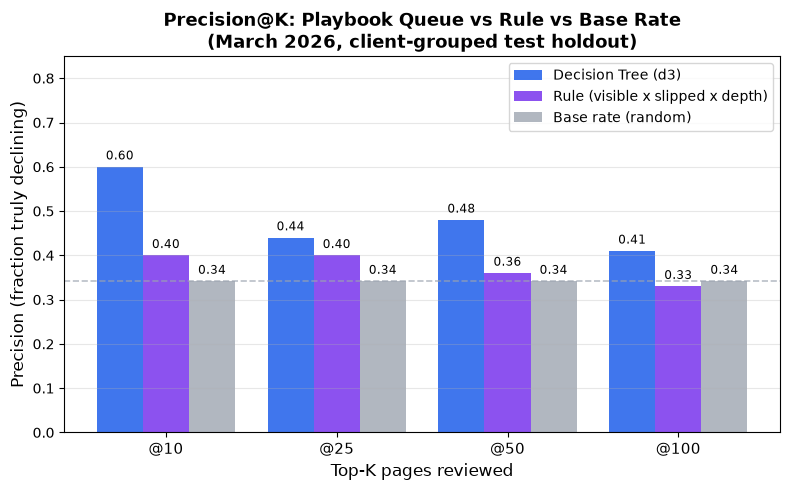

Saved: C:\Users\imtia\3.Hammad\projects\flyrank\FlyRank_Internship\work\figures\w07_precision_at_k.png


In [12]:
# Figure 1: Precision@K comparison bar chart
matplotlib.rcParams['font.family'] = 'DejaVu Sans'
KS_plot = [10, 25, 50, 100]
tree_vals = [precision_at_k(y_te, tree_proba_te, k) for k in KS_plot]
rule_vals = [precision_at_k(y_te, rule_scores_te, k) for k in KS_plot]
base_vals = [float(y_te.mean())] * len(KS_plot)

fig, ax = plt.subplots(figsize=(8, 5))
x = np.arange(len(KS_plot)); w = 0.27
b1 = ax.bar(x - w, tree_vals, w, label='Decision Tree (d3)', color='#2563EB', alpha=0.88)
b2 = ax.bar(x,     rule_vals, w, label='Rule (visible x slipped x depth)', color='#7C3AED', alpha=0.88)
b3 = ax.bar(x + w, base_vals, w, label='Base rate (random)', color='#9CA3AF', alpha=0.78)
ax.set_xlabel('Top-K pages reviewed', fontsize=12)
ax.set_ylabel('Precision (fraction truly declining)', fontsize=12)
ax.set_title('Precision@K: Playbook Queue vs Rule vs Base Rate\n(March 2026, client-grouped test holdout)', fontsize=13, fontweight='bold')
ax.set_xticks(x); ax.set_xticklabels([f'@{k}' for k in KS_plot], fontsize=11)
ax.set_ylim(0, 0.85)
ax.axhline(y_te.mean(), color='#9CA3AF', lw=1.2, ls='--', alpha=0.7)
ax.legend(fontsize=10); ax.grid(axis='y', alpha=0.3)
for bars in [b1, b2, b3]:
    for bar in bars:
        h = bar.get_height()
        ax.text(bar.get_x() + bar.get_width()/2, h + 0.01, f'{h:.2f}', ha='center', va='bottom', fontsize=8.5)
fig.tight_layout()
fp1 = FIG_DIR / 'w07_precision_at_k.png'
fig.savefig(fp1, dpi=150, bbox_inches='tight')
plt.show()
print(f'Saved: {fp1}')

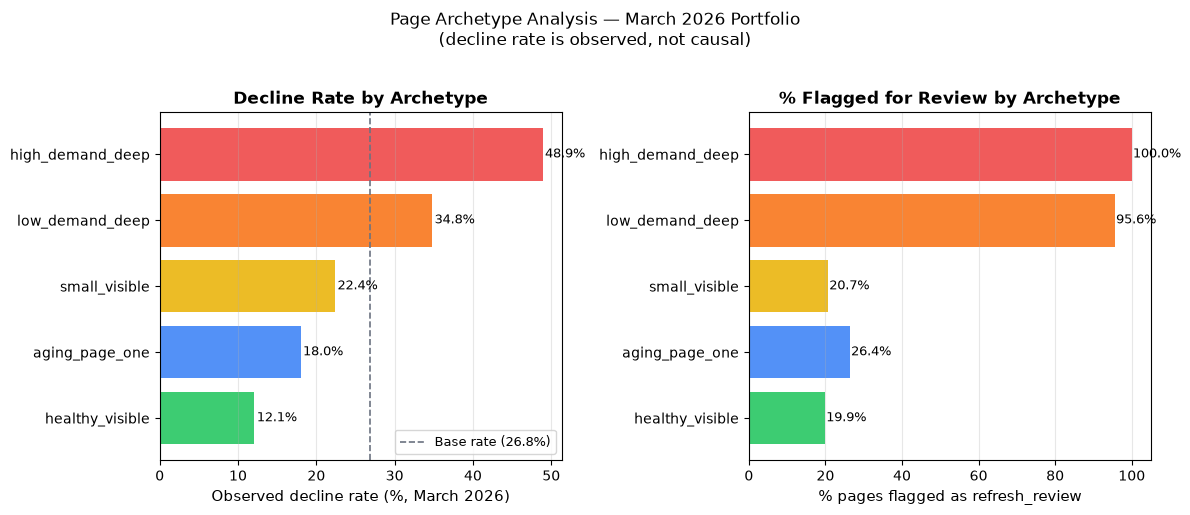

Saved: C:\Users\imtia\3.Hammad\projects\flyrank\FlyRank_Internship\work\figures\w07_archetype_breakdown.png


In [13]:
# Figure 2: Archetype breakdown (decline rate + % flagged)
arch_plot = arch_summary.reset_index().sort_values('decline_rate_pct', ascending=True)
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
bc = ['#22C55E', '#3B82F6', '#EAB308', '#F97316', '#EF4444'][:len(arch_plot)]

ax1 = axes[0]
bars1 = ax1.barh(arch_plot['archetype'], arch_plot['decline_rate_pct'], color=bc, alpha=0.88)
ax1.set_xlabel('Observed decline rate (%, March 2026)', fontsize=11)
ax1.set_title('Decline Rate by Archetype', fontsize=12, fontweight='bold')
ax1.axvline(df['is_declining_label'].mean()*100, color='#6B7280', ls='--', lw=1.2,
            label=f'Base rate ({df["is_declining_label"].mean()*100:.1f}%)')
ax1.legend(fontsize=9); ax1.grid(axis='x', alpha=0.3)
for bar in bars1:
    ax1.text(bar.get_width()+0.3, bar.get_y()+bar.get_height()/2, f'{bar.get_width():.1f}%', va='center', fontsize=9)

ax2 = axes[1]
bars2 = ax2.barh(arch_plot['archetype'], arch_plot['pct_flagged_pct'], color=bc, alpha=0.88)
ax2.set_xlabel('% pages flagged as refresh_review', fontsize=11)
ax2.set_title('% Flagged for Review by Archetype', fontsize=12, fontweight='bold')
ax2.grid(axis='x', alpha=0.3)
for bar in bars2:
    ax2.text(bar.get_width()+0.3, bar.get_y()+bar.get_height()/2, f'{bar.get_width():.1f}%', va='center', fontsize=9)

fig.suptitle('Page Archetype Analysis — March 2026 Portfolio\n(decline rate is observed, not causal)', fontsize=12, y=1.02)
fig.tight_layout()
fp2 = FIG_DIR / 'w07_archetype_breakdown.png'
fig.savefig(fp2, dpi=150, bbox_inches='tight')
plt.show()
print(f'Saved: {fp2}')

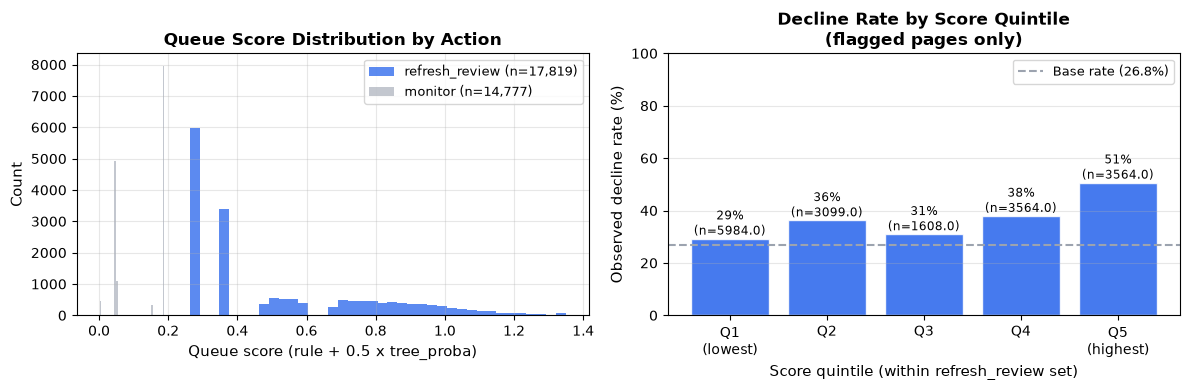

Saved: C:\Users\imtia\3.Hammad\projects\flyrank\FlyRank_Internship\work\figures\w07_queue_score_distribution.png


In [14]:
# Figure 3: Queue score distribution
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

ax1 = axes[0]
r_sc = queue[queue['action']=='refresh_review']['queue_score']
m_sc = queue[queue['action']=='monitor']['queue_score']
ax1.hist(r_sc, bins=40, color='#2563EB', alpha=0.75, label=f'refresh_review (n={len(r_sc):,})')
ax1.hist(m_sc, bins=40, color='#9CA3AF', alpha=0.60, label=f'monitor (n={len(m_sc):,})')
ax1.set_xlabel('Queue score (rule + 0.5 x tree_proba)', fontsize=11)
ax1.set_ylabel('Count', fontsize=11)
ax1.set_title('Queue Score Distribution by Action', fontsize=12, fontweight='bold')
ax1.legend(fontsize=9); ax1.grid(alpha=0.3)

ax2 = axes[1]
flagged_df = queue[queue['action']=='refresh_review'].copy()
flagged_df['score_bucket'] = pd.qcut(flagged_df['queue_score'], q=5,
    labels=['Q1\n(lowest)','Q2','Q3','Q4','Q5\n(highest)'])
bkt = (flagged_df.groupby('score_bucket', observed=True)
       .agg(n=('is_declining_label','size'), precision=('is_declining_label','mean')))
ax2.bar(bkt.index.astype(str), bkt['precision']*100, color='#2563EB', alpha=0.85, edgecolor='white')
ax2.axhline(df['is_declining_label'].mean()*100, color='#9CA3AF', ls='--',
            label=f'Base rate ({df["is_declining_label"].mean()*100:.1f}%)')
ax2.set_xlabel('Score quintile (within refresh_review set)', fontsize=11)
ax2.set_ylabel('Observed decline rate (%)', fontsize=11)
ax2.set_title('Decline Rate by Score Quintile\n(flagged pages only)', fontsize=12, fontweight='bold')
ax2.set_ylim(0, 100); ax2.legend(fontsize=9); ax2.grid(axis='y', alpha=0.3)
for i, (_, row) in enumerate(bkt.iterrows()):
    ax2.text(i, row['precision']*100+1.5, f'{row["precision"]*100:.0f}%\n(n={row["n"]})', ha='center', fontsize=8.5)

fig.tight_layout()
fp3 = FIG_DIR / 'w07_queue_score_distribution.png'
fig.savefig(fp3, dpi=150, bbox_inches='tight')
plt.show()
print(f'Saved: {fp3}')

In [15]:
exports = [
    (OUT_DIR / 'w07_ranked_action_queue.csv',     'queue CSV (gitignored)'),
    (OUT_DIR / 'w07_playbook_metrics.json',        'metrics receipt (committed)'),
    (FIG_DIR / 'w07_precision_at_k.png',           'precision@K figure (committed)'),
    (FIG_DIR / 'w07_archetype_breakdown.png',      'archetype figure (committed)'),
    (FIG_DIR / 'w07_queue_score_distribution.png', 'queue dist figure (committed)'),
]

print('Export verification:\n')
all_ok = True
for path, desc in exports:
    exists = path.exists()
    size_kb = path.stat().st_size / 1024 if exists else 0
    status = 'OK' if exists else 'MISSING'
    all_ok = all_ok and exists
    print(f'  [{status:7s}]  {desc:<43}  {size_kb:>7.1f} KB  {path.name}')

print()
if all_ok:
    print('All exports verified.')
    print('Commit: work/figures/*.png + work/outputs/w07_playbook_metrics.json')
    print('Do NOT commit: work/outputs/w07_ranked_action_queue.csv (gitignored by CI)')
else:
    print('WARNING: some exports missing — re-run cells above.')

Export verification:

  [OK     ]  queue CSV (gitignored)                        5958.7 KB  w07_ranked_action_queue.csv
  [OK     ]  metrics receipt (committed)                      2.2 KB  w07_playbook_metrics.json
  [OK     ]  precision@K figure (committed)                  65.4 KB  w07_precision_at_k.png
  [OK     ]  archetype figure (committed)                    85.5 KB  w07_archetype_breakdown.png
  [OK     ]  queue dist figure (committed)                   89.0 KB  w07_queue_score_distribution.png

All exports verified.
Commit: work/figures/*.png + work/outputs/w07_playbook_metrics.json
Do NOT commit: work/outputs/w07_ranked_action_queue.csv (gitignored by CI)


## Self-check

- [ ] **Section 1** — ranked actions + reason codes; archetype→action table; decay/refresh insight from w04 signal audit; cost/value thinking with real p@K numbers
- [ ] **Section 2** — intended use; 8 limits with evidence sources and suggested language
- [ ] **Section 3** — 6 required human checks; no-go list with 7 automation bans and justifications
- [ ] **Section 4** — 6 monitoring signals with thresholds; retrain criteria; light-monitoring list
- [ ] **Section 5** — 5 exports verified: queue CSV, metrics JSON, 3 figures
- [ ] **Runs top to bottom with no errors**
- [ ] **No client names, URLs, or private queries** anywhere
- [ ] **Claims use careful words:** observed, measured, directional, decision-support — no 'causes' or causal language
- [ ] **Figures committed** to `work/figures/` — paper builds on these next week
- [ ] **Queue CSV stays out of git** — CI will fail if committed; regenerate from this notebook
- [ ] **Committed** to `work/notebooks/w07_action_playbook.ipynb` — then submit repo URL on the card